In [1]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def comment(line, cell):
    pass   # do nothing, "commenting out" the cell

# for getting ot the right directory
import sys

#importing the necessary functions
sys.path.append("/nird/home/chrikap/Atmosphere_Ocean_Interactions_PhD/functions/nird_functions")
from common_NIRD_functions import*

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [4]:
experiments = ['piControl', 'abrupt-4xCO2']

ua_piControl_noresm2 = []
ua_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/ua/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_ua = yearly_avg(ds['ua'])

    if experiment == 'piControl':
        ua_piControl_noresm2 = yearly_ua
    elif experiment == 'abrupt-4xCO2':
        ua_x4CO2_noresm2 = yearly_ua

In [5]:
experiments = ['piControl', 'abrupt-4xCO2']

va_piControl_noresm2 = []
va_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/va/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_va = yearly_avg(ds['va'])

    if experiment == 'piControl':
    
        va_piControl_noresm2 = yearly_va
    else: 
        va_x4CO2_noresm2 = yearly_va

In [11]:
# Globall averaging the winds to create a timeseries
# Function for applyin the area weights to the fluxes
def areaavg(ds, var):
    _da = ds[var]
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"
    weighted = _da.weighted(weights)
    _daglob = weighted.mean(("lon", "lat"))
    return _daglob

# Function for calculating the global and hemisphgeric imbalance

def wind_gl_ave(model, wind):

    if model == 'IPSL-CM6A-LR':

        # Identify the equator index
        eq_idx = int((wind.lat == 0).argmax())
        
        # Southern Hemisphere: all lat < 0 + half of equator
        sh = wind.sel(lat=slice(None, 0))
        # Northern Hemisphere: all lat > 0 + half of equator
        nh = wind.sel(lat=slice(0, None))
        
        # Split the equator value
        eq_val = wind.sel(lat=0)
        sh.loc[dict(lat=0)] = eq_val / 2
        nh.loc[dict(lat=0)] = eq_val / 2

    else:
    
        sh = wind.sel(lat=slice(None,0)) 
        #print(sh)
        nh = wind.sel(lat=slice(0,None))
        #print(nh)
    
    sh_w = areaavg(sh.to_dataset(name = "restom"), "restom")
    nh_w = areaavg(nh.to_dataset(name = "restom"), "restom")
    
    glb_w = areaavg(wind.to_dataset(name = "restom"), "restom")

    return glb_w, nh_w, sh_w 

In [8]:
ua_x4CO2_s_noresm2 = ua_x4CO2_noresm2.isel(plev = 0)
va_x4CO2_s_noresm2 = va_x4CO2_noresm2.isel(plev = 0)

wind_x4CO2 = np.sqrt(ua_x4CO2_s_noresm2**2 + va_x4CO2_s_noresm2**2)

In [12]:
wind_x4CO2_gl, wind_x4CO2_nh, wind_x4CO2_sh = wind_gl_ave('NorESM2-LM', wind_x4CO2)

In [14]:
wind_x4CO2_gl_v = wind_x4CO2_gl.values

In [15]:
wind_x4CO2_nh_v = wind_x4CO2_nh.values
wind_x4CO2_sh_v = wind_x4CO2_sh.values

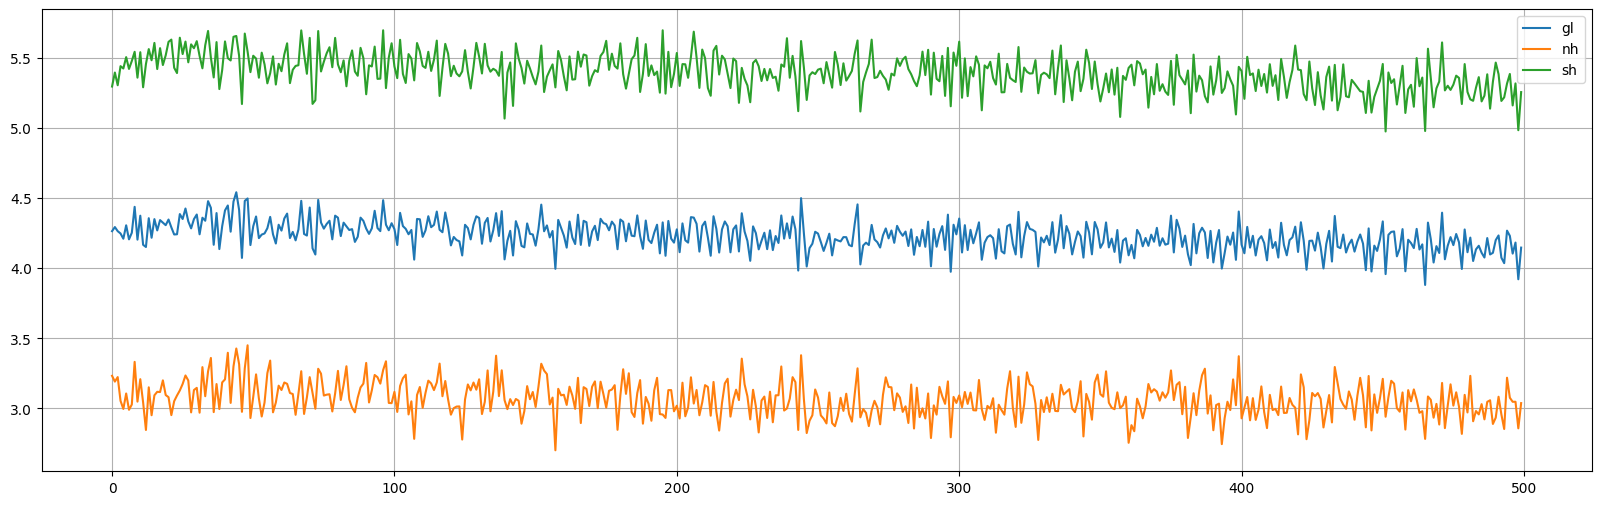

In [16]:
fig = plt.subplots(figsize=(20, 6))

plt.plot(wind_x4CO2_gl_v, label = 'gl')
plt.plot(wind_x4CO2_nh_v, label = 'nh')
plt.plot(wind_x4CO2_sh_v, label = 'sh')
plt.grid()
plt.legend()
plt.show()

In [17]:
ua_x4CO2_gl, ua_x4CO2_nh, ua_x4CO2_sh = wind_gl_ave('NorESM2-LM', ua_x4CO2_s_noresm2)
va_x4CO2_gl, va_x4CO2_nh, va_x4CO2_sh = wind_gl_ave('NorESM2-LM', va_x4CO2_s_noresm2)

In [18]:
ua_x4CO2_gl_v = ua_x4CO2_gl.values
ua_x4CO2_nh_v = ua_x4CO2_nh.values
ua_x4CO2_sh_v = ua_x4CO2_sh.values

va_x4CO2_gl_v = va_x4CO2_gl.values
va_x4CO2_nh_v = va_x4CO2_nh.values
va_x4CO2_sh_v = va_x4CO2_sh.values

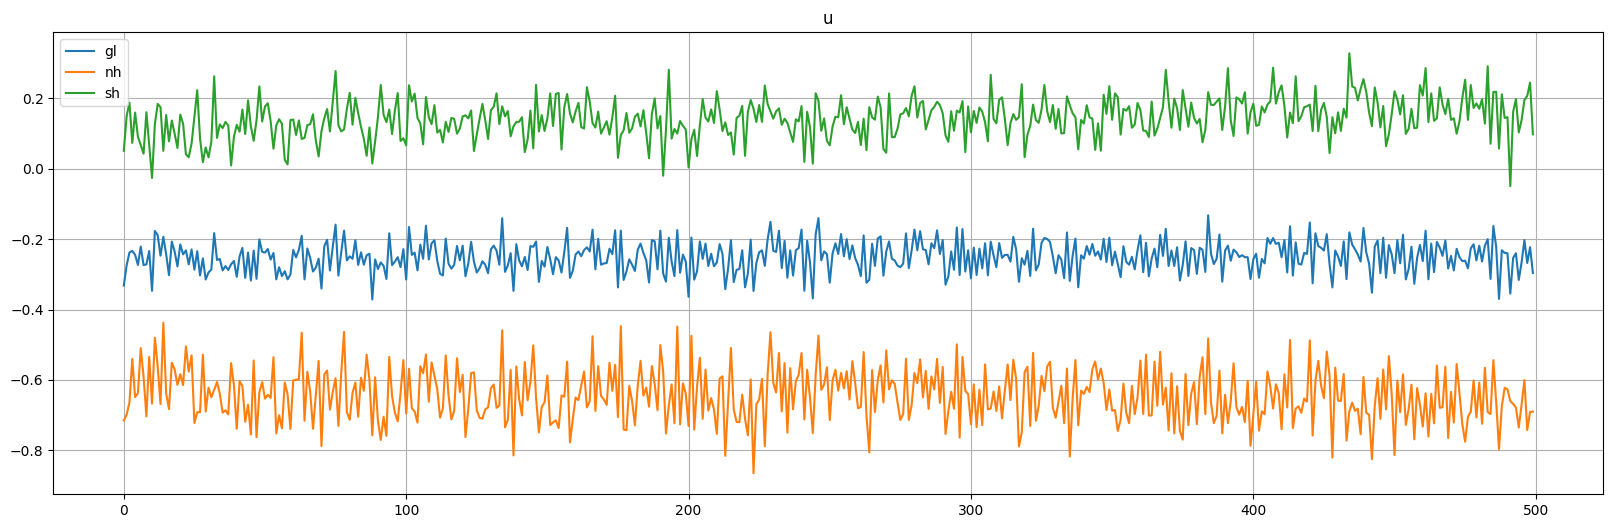

In [19]:
fig = plt.subplots(figsize=(20, 6))

plt.plot(ua_x4CO2_gl_v, label = 'gl')
plt.plot(ua_x4CO2_nh_v, label = 'nh')
plt.plot(ua_x4CO2_sh_v, label = 'sh')
plt.grid()
plt.legend()
plt.title('u')
plt.show()

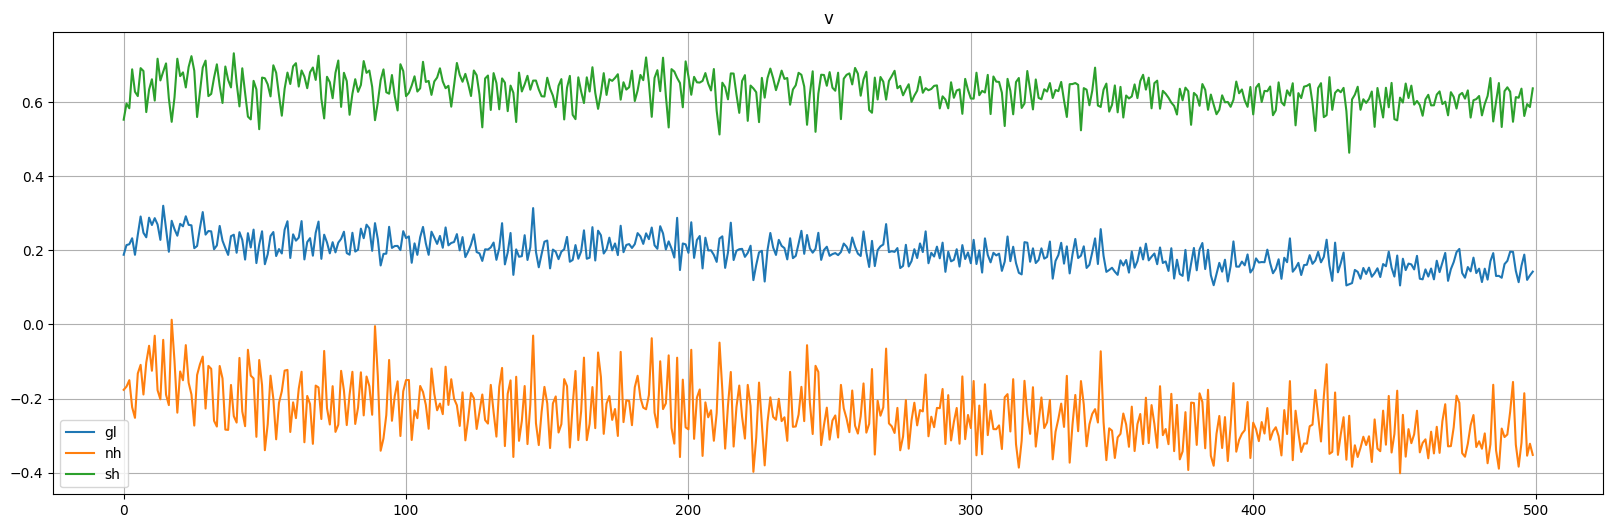

In [21]:
fig = plt.subplots(figsize=(20, 6))

plt.plot(va_x4CO2_gl_v, label = 'gl')
plt.plot(va_x4CO2_nh_v, label = 'nh')
plt.plot(va_x4CO2_sh_v, label = 'sh')
plt.grid()
plt.legend()
plt.title('v')
plt.show()

In [20]:
ua_piControl_noresm2_surf_0_30 = ua_piControl_noresm2.isel(plev = 0, year = slice(0, 30)).mean(dim = 'year').values
va_piControl_noresm2_surf_0_30 = va_piControl_noresm2.isel(plev = 0, year = slice(0, 30)).mean(dim = 'year').values

ua_x4CO2_noresm2_surf_0_30 = ua_x4CO2_noresm2.isel(plev = 0, year = slice(0, 30)).mean(dim = 'year').values
va_x4CO2_noresm2_surf_0_30 = va_x4CO2_noresm2.isel(plev = 0, year = slice(0, 30)).mean(dim = 'year').values

ua_x4CO2_noresm2_surf_120_150 = ua_x4CO2_noresm2.isel(plev = 0, year = slice(120, 150)).mean(dim = 'year').values
va_x4CO2_noresm2_surf_120_150 = va_x4CO2_noresm2.isel(plev = 0, year = slice(120, 150)).mean(dim = 'year').values

ua_x4CO2_noresm2_surf_470_500 = ua_x4CO2_noresm2.isel(plev = 0, year = slice(470, 500)).mean(dim = 'year').values
va_x4CO2_noresm2_surf_470_500 = va_x4CO2_noresm2.isel(plev = 0, year = slice(470, 500)).mean(dim = 'year').values

wind_piControl_noresm2 = np.sqrt(ua_piControl_noresm2_surf_0_30**2 + va_piControl_noresm2_surf_0_30**2)
wind_x4CO2_noresm2_0_30 = np.sqrt(ua_x4CO2_noresm2_surf_0_30**2 + va_x4CO2_noresm2_surf_0_30**2)
wind_x4CO2_noresm2_120_150 = np.sqrt(ua_x4CO2_noresm2_surf_120_150**2 + va_x4CO2_noresm2_surf_120_150**2)
wind_x4CO2_noresm2_470_500 = np.sqrt(ua_x4CO2_noresm2_surf_470_500**2 + va_x4CO2_noresm2_surf_470_500**2)

lat_noresm2 = ua_piControl_noresm2.lat.values
lon_noresm2 = ua_piControl_noresm2.lon.values

In [21]:
outdir = "/nird/home/chrikap/data/wind_data/"
os.makedirs(outdir, exist_ok=True)

np.save(outdir + "ua_piControl_noresm2_surf_0_30.npy", ua_piControl_noresm2_surf_0_30)
np.save(outdir + "va_piControl_noresm2_surf_0_30.npy", va_piControl_noresm2_surf_0_30)

np.save(outdir + "ua_x4CO2_noresm2_surf_0_30.npy", ua_x4CO2_noresm2_surf_0_30)
np.save(outdir + "va_x4CO2_noresm2_surf_0_30.npy", va_x4CO2_noresm2_surf_0_30)

np.save(outdir + "ua_x4CO2_noresm2_surf_120_150.npy", ua_x4CO2_noresm2_surf_120_150)
np.save(outdir + "va_x4CO2_noresm2_surf_120_150.npy", va_x4CO2_noresm2_surf_120_150)

np.save(outdir + "ua_x4CO2_noresm2_surf_470_500.npy", ua_x4CO2_noresm2_surf_470_500)
np.save(outdir + "va_x4CO2_noresm2_surf_470_500.npy", va_x4CO2_noresm2_surf_470_500)

np.save(outdir + "wind_piControl_noresm2.npy", wind_piControl_noresm2)
np.save(outdir + "wind_x4CO2_noresm2_0_30.npy", wind_x4CO2_noresm2_0_30)
np.save(outdir + "wind_x4CO2_noresm2_120_150.npy", wind_x4CO2_noresm2_120_150)
np.save(outdir + "wind_x4CO2_noresm2_470_500.npy", wind_x4CO2_noresm2_470_500)

np.save(outdir + "lat_noresm2.npy", lat_noresm2)
np.save(outdir + "lon_noresm2.npy", lon_noresm2)

In [3]:
load_dir = "/nird/home/chrikap/data/wind_data"

ua_piControl_noresm2_surf_0_30 = np.load(f'{load_dir}/ua_piControl_noresm2_surf_0_30.npy')
va_piControl_noresm2_surf_0_30 = np.load(f'{load_dir}/va_piControl_noresm2_surf_0_30.npy')
ua_x4CO2_noresm2_surf_0_30 = np.load(f'{load_dir}/ua_x4CO2_noresm2_surf_0_30.npy')
va_x4CO2_noresm2_surf_0_30 = np.load(f'{load_dir}/va_x4CO2_noresm2_surf_0_30.npy')
ua_x4CO2_noresm2_surf_120_150 = np.load(f'{load_dir}/ua_x4CO2_noresm2_surf_120_150.npy')
va_x4CO2_noresm2_surf_120_150 = np.load(f'{load_dir}/va_x4CO2_noresm2_surf_120_150.npy')
ua_x4CO2_noresm2_surf_470_500 = np.load(f'{load_dir}/ua_x4CO2_noresm2_surf_470_500.npy')
va_x4CO2_noresm2_surf_470_500 = np.load(f'{load_dir}/va_x4CO2_noresm2_surf_470_500.npy')
wind_piControl_noresm2 = np.load(f'{load_dir}/wind_piControl_noresm2.npy')
wind_x4CO2_noresm2_0_30 = np.load(f'{load_dir}/wind_x4CO2_noresm2_0_30.npy')
wind_x4CO2_noresm2_120_150 = np.load(f'{load_dir}/wind_x4CO2_noresm2_120_150.npy')
wind_x4CO2_noresm2_470_500 = np.load(f'{load_dir}/wind_x4CO2_noresm2_470_500.npy')
lat_noresm2 = np.load(f'{load_dir}/lat_noresm2.npy')
lon_noresm2 = np.load(f'{load_dir}/lon_noresm2.npy')

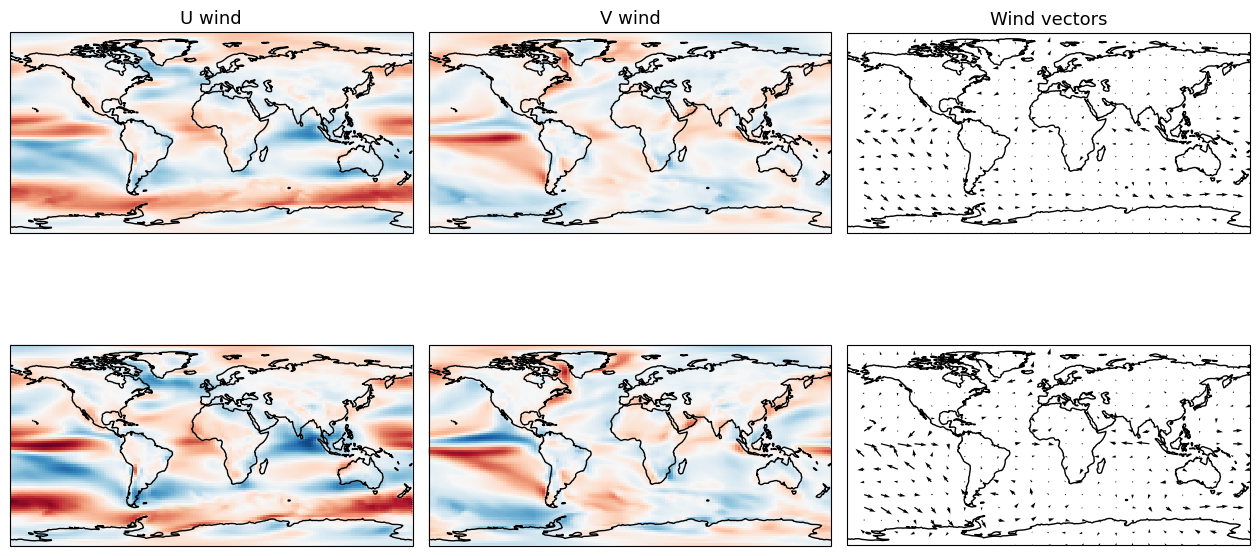

In [36]:
import cartopy.feature as cfeature

# organize data
u_data = [
    ua_x4CO2_noresm2_surf_120_150 - ua_piControl_noresm2_surf_0_30,
    ua_x4CO2_noresm2_surf_470_500 - ua_piControl_noresm2_surf_0_30
]

v_data = [
    va_x4CO2_noresm2_surf_120_150 - va_piControl_noresm2_surf_0_30,
    va_x4CO2_noresm2_surf_470_500 - va_piControl_noresm2_surf_0_30
]

wind_data = [
    wind_x4CO2_noresm2_120_150 - wind_piControl_noresm2,
    wind_x4CO2_noresm2_470_500 - wind_piControl_noresm2
]

rows = ["Years 120–150", "Years 470–500"]
cols = ["U wind", "V wind", "Wind vectors"]

uv_max = np.max(np.abs(np.concatenate([u_data, v_data])))

fig, axes = plt.subplots(
    2, 3,
    figsize=(16,8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plt.subplots_adjust(wspace=0.04, hspace=0.03)

mappables = [None, None]

# subsampling step for arrows
step = 6

for i in range(2):

    for j in range(3):

        ax = axes[i, j]

        if j < 2:

            data = [u_data, v_data][j][i]

            im = ax.pcolormesh(
                lon_noresm2,
                lat_noresm2,
                data,
                cmap="RdBu_r",
                vmin=-uv_max,
                vmax=uv_max,
                transform=ccrs.PlateCarree()
            )

            if mappables[j] is None:
                mappables[j] = im

        else:

            # wind arrows
            u = u_data[i]
            v = v_data[i]

            ax.quiver(
                lon_noresm2[::step],
                lat_noresm2[::step],
                u[::step, ::step],
                v[::step, ::step],
                transform=ccrs.PlateCarree(),
                scale=80
            )

        ax.coastlines()
        #ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        if j == 0:
            ax.set_ylabel(rows[i], fontsize=12)

        if i == 0:
            ax.set_title(cols[j], fontsize=13)

# colorbars only for first two columns
#for j in range(2):
#    fig.colorbar(
#        mappables[j],
#        ax=axes[:, j],
#        orientation="vertical",
#        fraction=0.035,
        pad=0.02
#    )
#
#plt.show()

In [ ]:
# decrease in the v direction and increase in the u direction

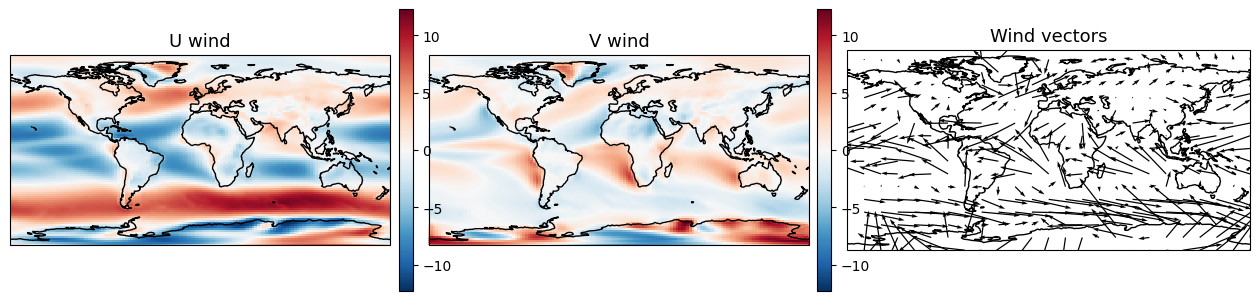

In [41]:

# organize data (piControl only)
u_data = [ua_piControl_noresm2_surf_0_30]
v_data = [va_piControl_noresm2_surf_0_30]

rows = ["piControl (Years 0–30)"]
cols = ["U wind", "V wind", "Wind vectors"]

uv_max = np.max(np.abs(np.concatenate([u_data, v_data])))

fig, axes = plt.subplots(
    1, 3,
    figsize=(16,4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plt.subplots_adjust(wspace=0.04)

mappables = [None, None]

# subsampling step for arrows
step = 6

for j in range(3):

    ax = axes[j]

    if j < 2:

        data = [u_data, v_data][j][0]

        im = ax.pcolormesh(
            lon_noresm2,
            lat_noresm2,
            data,
            cmap="RdBu_r",
            vmin=-uv_max,
            vmax=uv_max,
            transform=ccrs.PlateCarree()
        )

        if mappables[j] is None:
            mappables[j] = im

    else:

        u = ua_piControl_noresm2_surf_0_30
        v = va_piControl_noresm2_surf_0_30

        ax.quiver(
            lon_noresm2[::step],
            lat_noresm2[::step],
            u[::step, ::step],
            v[::step, ::step],
            transform=ccrs.PlateCarree(),
            scale=80
        )

    ax.coastlines()

    ax.set_title(cols[j], fontsize=13)

# colorbars for first two panels
for j in range(2):
    fig.colorbar(
        mappables[j],
        ax=axes[j],
        orientation="vertical",
        fraction=0.035,
        pad=0.02
    )

plt.show()

In [22]:
experiments = ['piControl', 'abrupt-4xCO2']

tauuo_piControl_noresm2 = []
tauuo_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/tauuo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_tauuo = yearly_avg(ds['tauuo'])

    if experiment == 'piControl':
        tauuo_piControl_noresm2 = yearly_tauuo
    elif experiment == 'abrupt-4xCO2':
        tauuo_x4CO2_noresm2 = yearly_tauuo

In [23]:
experiments = ['piControl', 'abrupt-4xCO2']

tauvo_piControl_noresm2 = []
tauvo_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/tauvo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_tauvo = yearly_avg(ds['tauvo'])

    if experiment == 'piControl':
        tauvo_piControl_noresm2 = yearly_tauvo
    elif experiment == 'abrupt-4xCO2':
        tauvo_x4CO2_noresm2 = yearly_tauvo

In [26]:
from tos_functions import *

In [28]:
tauvo_x4CO2_noresm2

<xarray.DataArray (year: 500, j: 385, i: 360)> Size: 554MB
dask.array<stack, shape=(500, 385, 360), dtype=float64, chunksize=(1, 385, 360), chunktype=numpy.ndarray>
Coordinates:
  * j          (j) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384 385
  * i          (i) int32 1kB 1 2 3 4 5 6 7 8 ... 353 354 355 356 357 358 359 360
    latitude   (j, i) float64 1MB -80.2 -80.2 -80.2 -80.2 ... 62.59 62.35 62.12
    longitude  (j, i) float64 1MB 250.5 251.5 252.5 253.5 ... 250.0 250.0 250.0
  * year       (year) int64 4kB 1 2 3 4 5 6 7 8 ... 494 495 496 497 498 499 500
Attributes:
    long_name:      Annual mean Sea Water Surface Downward Y Stress
    units:          N m-2
    standard_name:  downward_y_stress_at_sea_water_surface

In [47]:
lat = tauuo_x4CO2_noresm2["latitude"]
lon = tauuo_x4CO2_noresm2["longitude"]

ds_out = xr.Dataset({
    "lat": (["lat"], np.arange(-90, 90.5, 1)),
    "lon": (["lon"], np.arange(0, 360, 1)),
})

In [48]:
import xesmf as xe

ds_in_tauuo = xr.Dataset({
    "lat": lat,
    "lon": lon,
    "tauuo": tauuo_x4CO2_noresm2  # pick a timestep
})

regridder = xe.Regridder(ds_in_tauuo, ds_out, "bilinear")

tauuo_regrid = regridder(ds_in_tauuo["tauuo"])

In [49]:
ds_in_tauvo = xr.Dataset({
    "lat": tauvo_x4CO2_noresm2["latitude"],
    "lon": tauvo_x4CO2_noresm2["longitude"],
    "tauvo": tauvo_x4CO2_noresm2  # pick a timestep
})

regridder = xe.Regridder(ds_in_tauvo, ds_out, "bilinear")

tauvo_regrid = regridder(ds_in_tauvo["tauvo"])

In [50]:
tauuo_470_500 = tauuo_regrid.isel(year = slice(470, 500)).mean(dim = 'year').values
tauvo_470_500 = tauvo_regrid.isel(year = slice(470, 500)).mean(dim = 'year').values

In [51]:
tauuo_gl, tauuo_nh, tauuo_sh = wind_gl_ave('NorESM2-LM', tauuo_regrid)
tauvo_gl, tauvo_nh, tauvo_sh = wind_gl_ave('NorESM2-LM', tauvo_regrid)

In [52]:
tauuo_gl_v = tauuo_gl.values
tauuo_nh_v = tauuo_nh.values
tauuo_sh_v = tauuo_sh.values

In [53]:
tauvo_gl_v = tauvo_gl.values
tauvo_nh_v = tauvo_nh.values
tauvo_sh_v = tauvo_sh.values

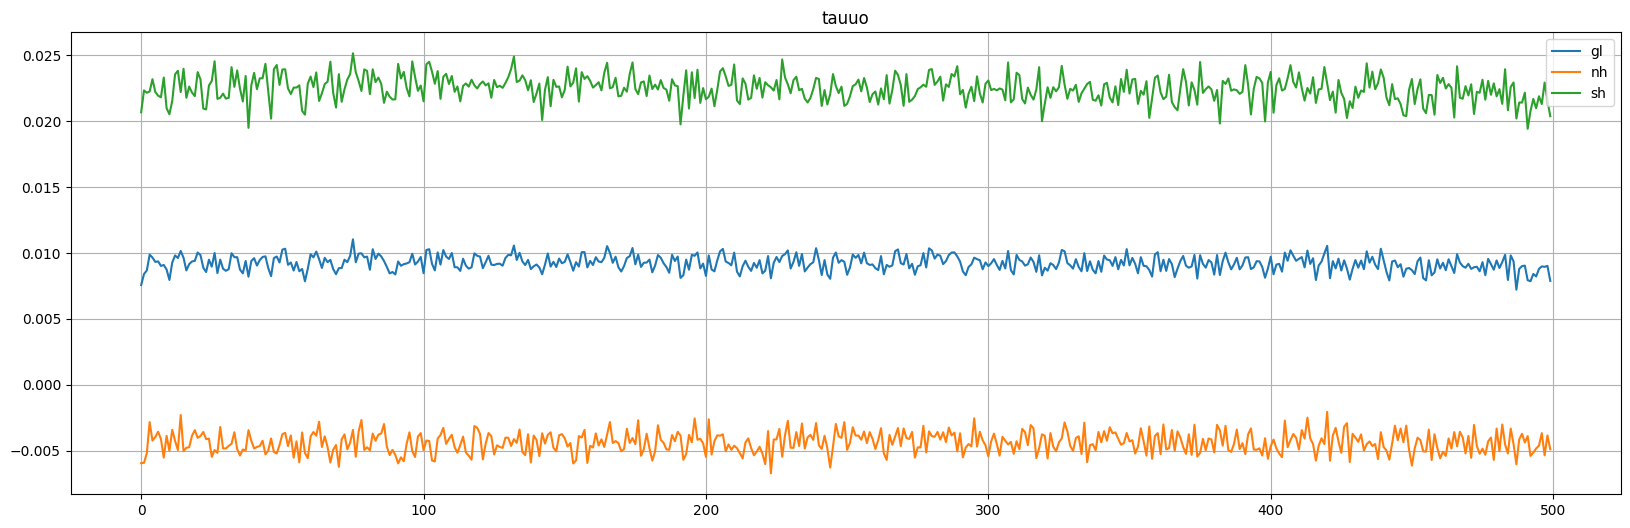

In [54]:
fig = plt.subplots(figsize=(20, 6))

plt.plot(tauuo_gl_v, label = 'gl')
plt.plot(tauuo_nh_v, label = 'nh')
plt.plot(tauuo_sh_v, label = 'sh')
plt.grid()
plt.legend()
plt.title('tauuo')
plt.show()

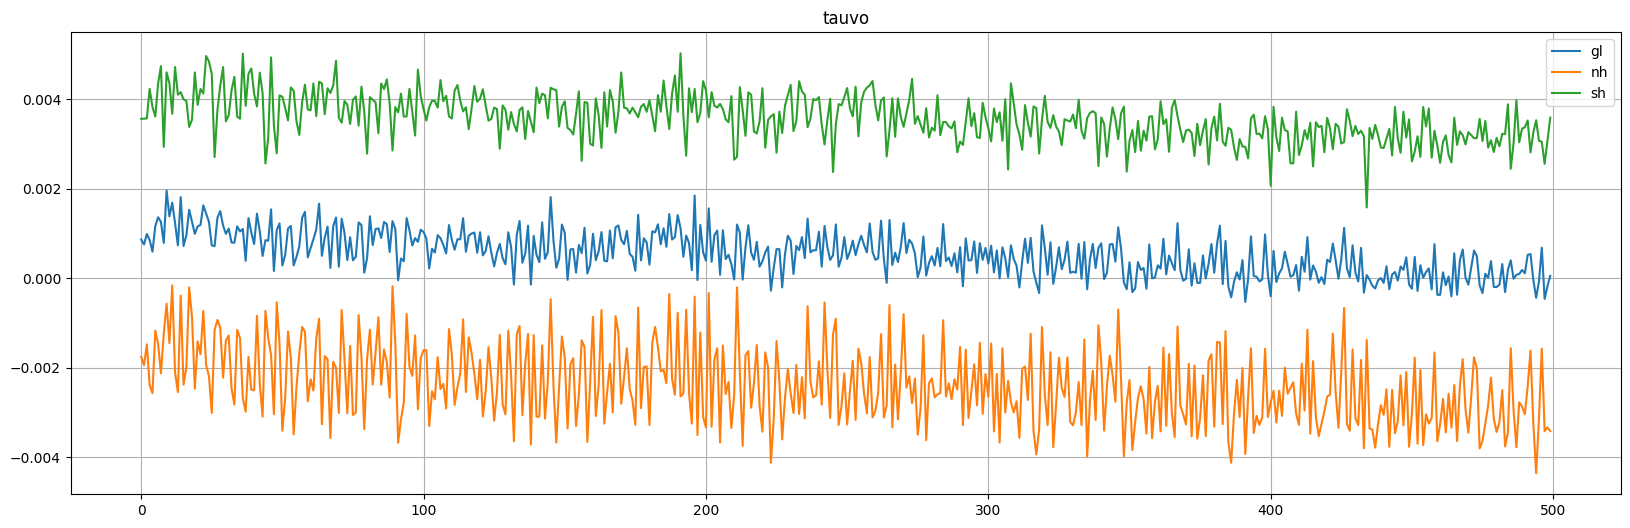

In [55]:
fig = plt.subplots(figsize=(20, 6))

plt.plot(tauvo_gl_v, label = 'gl')
plt.plot(tauvo_nh_v, label = 'nh')
plt.plot(tauvo_sh_v, label = 'sh')
plt.grid()
plt.legend()
plt.title('tauvo')
plt.show()